# GH Sequence Space — Week 2 Module

Part A: CAZy family download -> length/redundancy inspection -> MMseqs2 clustering -> Sequence Similarity Network (SSN) ->

Part B: Structural modelling (Chai-1).

This notebook starts with **Step 1: downloading a CAZy family**. Set `GH_FAMILY` below to whichever family you want to explore (e.g. `GH26`).

### Before you start

**⏩ Run the slow cells before the exercise slot begins.** You will be told in class when. Open the
notebook during the lecture before and run from the top down to and including **Fetch NCBI Sequences
in Batches** — that is the longest wait in the notebook, and it finishes while the lecture is still
going. Your 30 minutes then go on the analysis instead of on a progress bar. **Leave the tab open**;
a closed Colab session loses everything.

This notebook maps the **sequence space of a CAZy glycoside hydrolase family (enzymes that break the chemical bonds in complex sugars)**: download the family,
fetch its sequences, cluster them, and draw the result as a network. Nothing here needs a GPU — the
default Colab CPU runtime is fine.

Two cells are slow, and both are flagged again where they appear:

| Cell | Typical wait | When to run it |
|---|---|---|
| *Fetch NCBI Sequences in Batches* | **5–15 min** | **before the exercise slot** |
| *all-vs-all pairwise search* | **3–10 min** | during the slot — the result is cached, so re-runs are instant |

While a cell runs, Colab shows a spinner beside it and a square ■ stop button in the toolbar.
**A cell with no visible output is usually still working — do not restart the runtime.**

Run the cells **in order from the top**: later cells reuse variables made earlier. If you hit
`NameError: 'cazy_df' is not defined`, you skipped a cell or the session was reset — go back to the
top and run down again.

> **Terms used in this notebook**
>
> **CAZy** — the database of Carbohydrate-Active enZymes, sorted into families by sequence similarity.
> **GH26** is glycoside hydrolase family 26, mostly mannanases.
> **Accession** — a database's ID for one sequence (GenBank IDs here). **FASTA** — the plain-text
> sequence format: a line starting with `>` naming the sequence, then the sequence itself.
> **Characterised** — an enzyme whose activity has actually been measured in a lab, as opposed to
> one that is only *predicted* to be a GH26 from its sequence. Most entries are the latter.
> **Sequence identity** — the percentage of aligned positions where the two residues are the same.
> **Coverage** — the fraction of a sequence that the alignment spans. High identity over 20% of the
> length and high identity over 90% are very different claims.
> **Clustering** — grouping sequences that are similar enough to count as "the same thing". Each
> cluster gets one **representative** sequence.
> **All-vs-all search** — compare every sequence with every other one. The work grows with the square
> of the number of sequences, which is why that cell is slow.
> **Sequence similarity network (SSN)** — a graph in which every sequence is a **node** and an
> **edge** joins two sequences whose similarity beats a threshold. Groups of connected nodes
> (**components**) are a rough picture of subfamilies. Raising the threshold breaks the network
> into more, smaller pieces.
> **Bit score / E-value** — explained in Exercise 1, Part 2. Bigger bits = better match; smaller
> E-value = less likely to be chance.

## 1. Fetch CAZy family accession list

In [6]:
# @title CAZy family to explore
# =======================================================================
# Config -- set the family here, everything downstream reuses this
# =======================================================================
GH_FAMILY = "GH26" # @param {type:"string"}

import pandas as pd
from pathlib import Path

work_dir = Path(GH_FAMILY)
work_dir.mkdir(exist_ok=True)

GH_FAMILY

'GH26'

## Fetch Entry Data from CAZy

> **Downloads live from cazy.org.** Usually a few seconds. The CAZy server is occasionally slow or
> briefly unavailable — if the download fails, tick `Upload_CAZy_File` and supply the `.txt` yourself
> rather than waiting.

In [7]:
# @title Download Data from CAZy or Use Uploaded File
# Please select ONE option below. If both are selected, 'Use Uploaded CAZy File' will be prioritized.
Download_from_CAZy = True # @param {type:"boolean"}
Upload_CAZy_File = False # @param {"type":"boolean"}

import pandas as pd
from pathlib import Path
import requests
from google.colab import files # Import google.colab.files for upload functionality

cazy_url = f"https://www.cazy.org/IMG/cazy_data/{GH_FAMILY}.txt"
standard_cazy_file_path = work_dir / f"{GH_FAMILY}.txt"

loaded_cazy_df = pd.DataFrame()
data_loaded_successfully = False

# --- Determine action based on user selection ---
if Upload_CAZy_File:
    # Prioritize loading an uploaded file if selected
    if standard_cazy_file_path.exists():
        print(f"Loading data from existing local file: {standard_cazy_file_path}")
        try:
            loaded_cazy_df = pd.read_csv(
                standard_cazy_file_path,
                header=None,
                sep="\t",
                names=["family", "kingdom", "organism", "genbank_accession", "source"],
            )
            data_loaded_successfully = True
            print(f"Successfully loaded {len(loaded_cazy_df)} entries from local file.")
        except Exception as e:
            print(f"Error loading data from {standard_cazy_file_path}: {e}")
            print("Please ensure the local file is correctly formatted or re-upload it.")
    else:
        print(f"'{GH_FAMILY}.txt' not found locally. Please upload the file now.")
        try:
            uploaded = files.upload()
            if uploaded:
                for filename, content in uploaded.items():
                    # Save the uploaded file with the standard name
                    with open(standard_cazy_file_path, 'wb') as f:
                        f.write(content)
                    print(f"File '{filename}' uploaded successfully and saved as '{standard_cazy_file_path}'.")
                    break # Assuming only one file is relevant
                # After successful upload, try to load it
                if standard_cazy_file_path.exists():
                    try:
                        loaded_cazy_df = pd.read_csv(
                            standard_cazy_file_path,
                            header=None,
                            sep="\t",
                            names=["family", "kingdom", "organism", "genbank_accession", "source"],
                        )
                        data_loaded_successfully = True
                        print(f"Successfully loaded {len(loaded_cazy_df)} entries from uploaded file.")
                    except Exception as e:
                        print(f"Error loading data from uploaded file {standard_cazy_file_path}: {e}")
                        print("Please ensure the uploaded file is correctly formatted.")
            else:
                print("No file was uploaded. Please upload the file or select 'Download from CAZy'.")
        except Exception as e:
            print(f"Error during file upload: {e}")

elif Download_from_CAZy:
    # Attempt to download if 'Download_from_CAZy' is selected and 'Upload_CAZy_File' is False
    if standard_cazy_file_path.exists():
        print(f"Local file {standard_cazy_file_path} already exists. Skipping download and loading it.")
        try:
            loaded_cazy_df = pd.read_csv(
                standard_cazy_file_path,
                header=None,
                sep="\t",
                names=["family", "kingdom", "organism", "genbank_accession", "source"],
            )
            data_loaded_successfully = True
            print(f"Successfully loaded {len(loaded_cazy_df)} entries from existing local file.")
        except Exception as e:
            print(f"Error loading data from {standard_cazy_file_path}: {e}")
            print("Please ensure the existing local file is correctly formatted or delete it to force re-download.")
    else:
        print(f"Attempting to download {GH_FAMILY}.txt from {cazy_url} using requests...")
        try:
            response = requests.get(cazy_url, timeout=30)
            response.raise_for_status()
            with open(standard_cazy_file_path, 'wb') as f:
                f.write(response.content)
            print("Download complete.")
            loaded_cazy_df = pd.read_csv(
                standard_cazy_file_path,
                header=None,
                sep="\t",
                names=["family", "kingdom", "organism", "genbank_accession", "source"],
            )
            data_loaded_successfully = True
            print(f"Successfully loaded {len(loaded_cazy_df)} entries from downloaded file.")
        except requests.exceptions.RequestException as e:
            print(f"Error downloading file from {cazy_url}: {e}")
            print("Please check the URL, your internet connection, or try again later.")
            print(f"Consider uploading '{GH_FAMILY}.txt' using the upload cell and selecting 'Upload CAZy File'.")
        except Exception as e:
            print(f"Error loading downloaded data from {standard_cazy_file_path}: {e}")

else: # Neither option is selected
    print("No data retrieval method selected. Please select either 'Download from CAZy' or 'Upload CAZy File'.")
    print("0 entries loaded. cazy_df is empty.")

# --- Final Assignment and Display ---
cazy_df = loaded_cazy_df

if data_loaded_successfully:
    print(f"\nFinal cazy_df contains {len(cazy_df)} entries for {GH_FAMILY}.")
    display(cazy_df.head())
    display(cazy_df.tail())
else:
    print("\nNo data loaded into cazy_df. It remains empty.")
    display(cazy_df.head())
    display(cazy_df.tail())

Local file GH26/GH26.txt already exists. Skipping download and loading it.
Successfully loaded 8414 entries from existing local file.

Final cazy_df contains 8414 entries for GH26.


,family,kingdom,organism,genbank_accession,source
0,GH26,Eukaryota,Aaosphaeria arxii CBS 175.79 v1.0,368360,jgi
1,GH26,Bacteria,Abditibacteriota bacterium IAD-21,BCM90821.1,ncbi
2,GH26,Bacteria,Abditibacteriota bacterium IAD-21,BCM89627.1,ncbi
3,GH26,Bacteria,Abditibacteriota bacterium IAD-21,BCM91371.1,ncbi
4,GH26,Bacteria,Abditibacteriota bacterium IAD-21,BCM93856.1,ncbi


,family,kingdom,organism,genbank_accession,source
8409,GH26,Bacteria,Zunongwangia sp. HRR-M8,WBL23115.1,ncbi
8410,GH26,Bacteria,Zunongwangia sp. SCSIO 43204,UAB85035.1,ncbi
8411,GH26,Bacteria,Zunongwangia sp. SCSIO 43204,UAB86479.1,ncbi
8412,GH26,Bacteria,Zunongwangia sp. SCSIO 43204,UAB85023.1,ncbi
8413,GH26,Bacteria,Zunongwangia sp. SCSIO 43204,UAB85027.1,ncbi


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## Fetch HTML with characterized GH26s

In [8]:
# @title Download the characterised GH26 list from the course repo
# CAZy's listing of characterised GH26 entries is kept in the course repository,
# so there is nothing to upload by hand.
!wget -q -O GH26_characterized.html https://raw.githubusercontent.com/UadKLab/27200_Data-Driven-Bioengineering/main/weeks/week02_sequence_structure_and_ptms/data/GH26_characterized.html
!ls -lh GH26_characterized.html

-rw-r--r-- 1 root root 124K Sep 11 14:16 GH26_characterized.html


In [37]:
# @title ####Parse Characterized Members (from HTML to CSV)
import pandas as pd
from pathlib import Path

html_file_name = "GH26_characterized.html"
html_file_path = Path(html_file_name)

if not html_file_path.exists() or html_file_path.stat().st_size == 0:
    raise FileNotFoundError(
        f"'{html_file_name}' is missing or empty. Run the download cell above first."
    )

tables = pd.read_html(html_file_path)
main_table = tables[1]

col_names = ["Protein Name", "EC#", "Reference", "Organism", "GenBank", "Uniprot", "PDB/3D"]
main_table = main_table.iloc[:, :7].copy()   # <-- .copy() added here
main_table.columns = col_names

divider_mask = main_table.apply(lambda r: r.nunique() == 1, axis=1)
kingdom_rows = main_table[divider_mask]["Protein Name"]

main_table["Kingdom"] = None
for idx, kingdom in kingdom_rows.items():
    main_table.loc[idx, "Kingdom"] = kingdom
main_table["Kingdom"] = main_table["Kingdom"].ffill()

main_table = main_table[~divider_mask].copy()   # <-- .copy() added here too
main_table = main_table[main_table["Protein Name"] != "Protein Name"]
main_table = main_table[["Kingdom", "Protein Name", "EC#", "Reference", "Organism", "GenBank", "Uniprot", "PDB/3D"]].reset_index(drop=True)

main_table.to_csv("GH26_characterized.csv", index=False)

print("Content of GH26_characterized.csv:")
display(pd.read_csv("GH26_characterized.csv"))


Content of GH26_characterized.csv:


,Kingdom,Protein Name,EC#,Reference,Organism,GenBank,Uniprot,PDB/3D
0,Bacteria,β-mannanase (Man;CtMan;CtManf;Cthe_0032),3.2.1.78,pubmed,Acetivibrio thermocellus ATCC 27405,ABN51273.1,A3DBE4,NaN
1,Bacteria,β-mannanase (ManA; ManB; Cthe_2811) (Man26B),3.2.1.78,pubmed,Acetivibrio thermocellus ATCC 27405,ABN54010.1,A3DJ81,NaN
2,Bacteria,β-mannanase 26B (Man26B),3.2.1.78,pubmed,Acetivibrio thermocellus F1,BAB19050.1,Q9F1T9,NaN
3,Bacteria,"endo-β-1,4-glucanase / β-1,3:1,4-glucanase H (...",3.2.1.73,pubmed,Acetivibrio thermocellus NCIB 10682,AAA23225.1,H6SHY4 P16218,2BV9[A] 2BVD[A] 2CIP[A] 2CIT[A] 2V3G[A] 2VI0[A...
4,Bacteria,β-mannanase A (ManA) (Man26A),3.2.1.78,pubmed,Acetivibrio thermocellus YS,CAB52403.1,Q9REC7,NaN
...,...,...,...,...,...,...,...,...
90,Eukaryota,β-mannanase (mannobiose-producing) (RsManH;RsM...,3.2.1.100,pubmed,Symbiotic protist of Reticulitermes speratus,BAN57513.1,A0A060N6J6,NaN
91,Eukaryota,"endo-β-1,4-mannanase 26A (WspMan26A)",3.2.1.78,pubmed,Westerdykella sp.,AXG24385.1,A0A345F7H7,NaN
92,Eukaryota,"endo-β-1,4-mannanase 26A (YpenMan26A)",3.2.1.78,pubmed,Yunnania penicillata Man26A,AYU65281.1,A0A3G4RHU4,6HPF[A]
93,unclassified,"endo-β-1,4-mannanase precursor (ManEM17)",3.2.1.78,pubmed,insect gut metagenome,ARK08557.1,A0A1W6DZL1,NaN


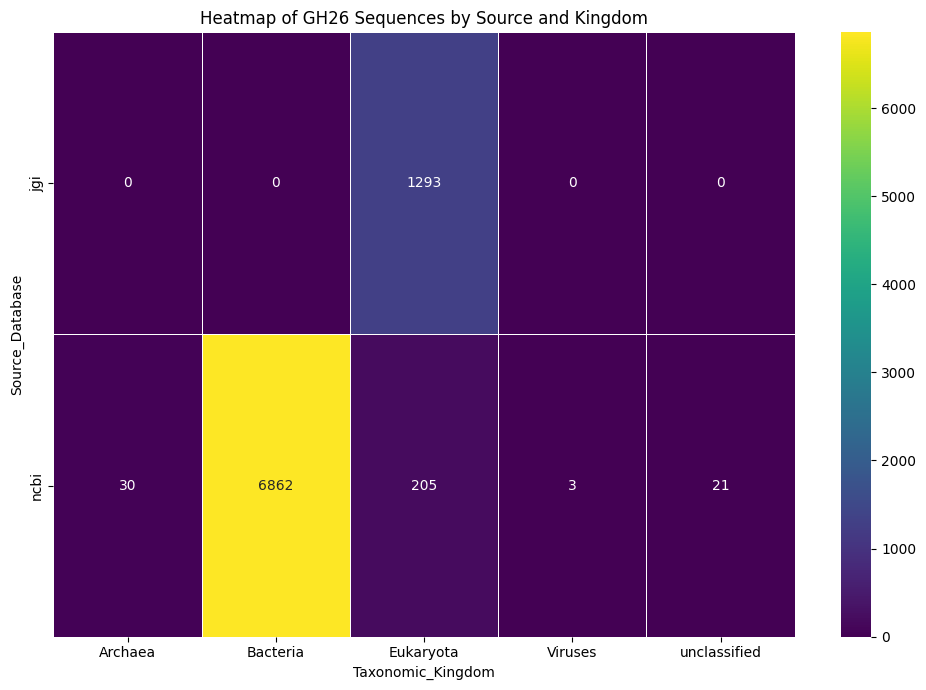

In [10]:
# @title Heatmap of Sequences by Source and Kingdom
import matplotlib.pyplot as plt
import seaborn as sns

# Group by source and kingdom, then count occurrences
taxon_counts = cazy_df.groupby(['source', 'kingdom']).size().unstack(fill_value=0)

# Create the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(taxon_counts, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title(f'Heatmap of {GH_FAMILY} Sequences by Source and Kingdom')
plt.xlabel('Taxonomic_Kingdom')
plt.ylabel('Source_Database')
plt.tight_layout()
plt.show()

This heatmap visualizes the number of sequences for each combination of `source database` (NCBI or JGI) and `Taxonomic_kingdom`. The numbers in the cells indicate the count of sequences, and the color intensity represents higher counts.

# **QUESTIONS**
### How many entries are in this CAZy family ?

**Solution**
This is written a bit further up in the document as one if the outputs: Final cazy_df contains 8414 entries for GH26.


### What is the origin of the sequences ?

**Solution**
Not sure if I understand it correctly, but if it means where the data was retrieved from then it is from NCBI and JGI.


### How many characterized enzymes ?

**Solution**
The characterisization table has 95 rows, which means that it has characterized 95 enzymes.



---

# **2. Fetch sequences from NCBI**
## Since fetching sequences from JGI is not trivial, we will now fetch sequence from NCBI



In [11]:
# @title Split NCBI and JGI entries
# @title
import pandas as pd

# Define the output file paths
ncbi_output_path = work_dir / f"{GH_FAMILY}_ncbi.txt"
jgi_output_path = work_dir / f"{GH_FAMILY}_jgi.txt"

# Filter the DataFrame for 'ncbi' source and save
cazy_df[cazy_df['source'] == 'ncbi'].to_csv(ncbi_output_path, sep='\t', index=False, header=False)
print(f"Saved NCBI-sourced entries to {ncbi_output_path}")

# Filter the DataFrame for 'jgi' source and save
cazy_df[cazy_df['source'] == 'jgi'].to_csv(jgi_output_path, sep='\t', index=False, header=False)
print(f"Saved JGI-sourced entries to {jgi_output_path}")

# Display the first few lines of the newly created files to verify
print("\nFirst 5 lines of GH26_ncbi.txt:")
!head -n 5 {ncbi_output_path}

print("\nFirst 5 lines of GH26_jgi.txt:")
!head -n 5 {jgi_output_path}

Saved NCBI-sourced entries to GH26/GH26_ncbi.txt
Saved JGI-sourced entries to GH26/GH26_jgi.txt

First 5 lines of GH26_ncbi.txt:
GH26	Bacteria	Abditibacteriota bacterium IAD-21	BCM90821.1	ncbi
GH26	Bacteria	Abditibacteriota bacterium IAD-21	BCM89627.1	ncbi
GH26	Bacteria	Abditibacteriota bacterium IAD-21	BCM91371.1	ncbi
GH26	Bacteria	Abditibacteriota bacterium IAD-21	BCM93856.1	ncbi
GH26	Bacteria	Abditibacteriota bacterium IAD-21	BCM89777.1	ncbi

First 5 lines of GH26_jgi.txt:
GH26	Eukaryota	Aaosphaeria arxii CBS 175.79 v1.0	368360	jgi
GH26	Eukaryota	Acephala macrosclerotiorum EW76-UTF0540 v1.0	734998	jgi
GH26	Eukaryota	Achaetomium macrosporum CBS 532.94 v1.0	31484	jgi
GH26	Eukaryota	Achaetomium strumarium CBS333.67 v1.0	388224	jgi
GH26	Eukaryota	Acidomyces richmondensis BFW	75586	jgi


## Fetch sequences from NCBI

In [12]:
# @title Prepare NCBI Accessions Dataframe
# Load accessions from GH26_ncbi.txt
ncbi_file_path = work_dir / f"{GH_FAMILY}_ncbi.txt"

# Read the file, assuming tab-separated and accession is the 4th column (index 3)
ncbi_df = pd.read_csv(ncbi_file_path, sep='\t', header=None,
                       names=['family', 'kingdom', 'organism', 'genbank_accession', 'source',
                              'genus', 'TaxID_Genus_x', 'Superkingdom_Genus_x', 'Phylum_Genus_x',
                              'Class_Genus_x', 'Order_Genus_x', 'Family_Genus_x', 'ScientificName_Genus_x',
                              'TaxID_Genus_y', 'Superkingdom_Genus_y', 'Phylum_Genus_y',
                              'Class_Genus_y', 'Order_Genus_y', 'Family_Genus_y', 'ScientificName_Genus_y', 'Phylum_Genus_Clean'])

accessions = ncbi_df['genbank_accession'].dropna().tolist()
print(f"Loaded {len(accessions)} accessions from {ncbi_file_path}")

Loaded 7121 accessions from GH26/GH26_ncbi.txt


In [13]:
# @title Install Biopython
!pip install -q biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 41.9 MB/s eta 0:00:00


### ⚠️ Read this before running the next cell

**1. Replace the placeholder email with your own institutional address.** Near the bottom of the
cell you will find:

```python
my_entrez_email = "your.email@example.com"   # <-- put your institutional email here
```

Change it to your **DTU address** before running. NCBI asks every automated query to identify
itself, so this field is not optional — put your real institutional email in, not a personal one and
not the placeholder.

**2. This is the slowest cell in the notebook — 5 to 15 minutes, so run it *before* the exercise slot.** It fetches several thousand
protein sequences in batches of 200, pausing between batches to stay under NCBI's rate limit
(3 requests per second without an API key). You will see one `Fetching 0-200 of ...` line per batch.

**Long pauses between those lines are normal.** Do not restart the runtime, and do not re-run the
cell because it looks stuck — restarting means starting the download again from zero.

*Optional:* an [NCBI API key](https://ncbiinsights.ncbi.nlm.nih.gov/2017/11/02/new-api-keys-for-the-e-utilities/)
raises the limit to 10 requests/second and roughly halves the wait. Uncomment the two `api_key` lines
if you have one.

In [14]:
# @title Fetch NCBI Sequences in Batches
from Bio import Entrez, SeqIO
import time
from IPython.display import display, Markdown # Import display and Markdown

def fetch_sequences_in_batches(accessions_list, batch_size, entrez_email, entrez_api_key=None):
    """
    Fetches protein sequences from NCBI using Entrez in batches.

    Args:
        accessions_list (list): A list of GenBank accession numbers.
        batch_size (int): The number of accessions to fetch in each batch.
        entrez_email (str): Your email address for Entrez.
        entrez_api_key (str, optional): Your NCBI API key. Defaults to None.

    Returns:
        list: A list of Biopython SeqRecord objects.
    """
    Entrez.email = entrez_email
    if entrez_api_key:
        Entrez.api_key = entrez_api_key

    records = []
    total_accessions = len(accessions_list)

    for i in range(0, total_accessions, batch_size):
        batch = accessions_list[i:i + batch_size]
        print(f"Fetching {i}-{min(i + batch_size, total_accessions)} of {total_accessions}...")
        try:
            handle = Entrez.efetch(
                db="protein",
                id=",".join(batch),
                rettype="fasta",
                retmode="text",
            )
            batch_records = list(SeqIO.parse(handle, "fasta"))
            records.extend(batch_records)
            handle.close()
        except Exception as e:
            print(f"  Batch failed ({e}), retrying individually...")
            for acc in batch:
                try:
                    handle = Entrez.efetch(db="protein", id=acc, rettype="fasta", retmode="text")
                    records.extend(list(SeqIO.parse(handle, "fasta")))
                    handle.close()
                except Exception as e2:
                    print(f"    Failed: {acc} ({e2})")
        time.sleep(0.4)  # stay under NCBI's rate limit

    print(f"\nRetrieved {len(records)} sequences out of {total_accessions} accessions")
    return records

# Set your Entrez email (REQUIRED)
my_entrez_email = "your.email@example.com"  # <-- REPLACE with your institutional email, e.g. sXXXXXX@dtu.dk
# Set your NCBI API key (OPTIONAL, uncomment if you have one)
# my_entrez_api_key = "your_ncbi_api_key"

# Define batch size
BATCH_SIZE = 200

# Call the function to fetch sequences
records = fetch_sequences_in_batches(
    accessions,
    BATCH_SIZE,
    my_entrez_email,
    # entrez_api_key=my_entrez_api_key # Uncomment if using an API key
)

# Display the summary using IPython.display.Markdown for proper rendering
display(Markdown("""
### Summary of NCBI Sequence Fetching

This cell defines and executes the `fetch_sequences_in_batches` function
to retrieve protein sequences from NCBI. Accessions were successfully fetched.
"""))

Fetching 0-200 of 7121...
Fetching 200-400 of 7121...
Fetching 400-600 of 7121...
Fetching 600-800 of 7121...
Fetching 800-1000 of 7121...
Fetching 1000-1200 of 7121...
Fetching 1200-1400 of 7121...
Fetching 1400-1600 of 7121...
Fetching 1600-1800 of 7121...
Fetching 1800-2000 of 7121...
Fetching 2000-2200 of 7121...
Fetching 2200-2400 of 7121...
Fetching 2400-2600 of 7121...
Fetching 2600-2800 of 7121...
Fetching 2800-3000 of 7121...
Fetching 3000-3200 of 7121...
Fetching 3200-3400 of 7121...
Fetching 3400-3600 of 7121...
Fetching 3600-3800 of 7121...
Fetching 3800-4000 of 7121...
Fetching 4000-4200 of 7121...
Fetching 4200-4400 of 7121...
Fetching 4400-4600 of 7121...
Fetching 4600-4800 of 7121...
Fetching 4800-5000 of 7121...
Fetching 5000-5200 of 7121...
Fetching 5200-5400 of 7121...
Fetching 5400-5600 of 7121...
Fetching 5600-5800 of 7121...
Fetching 5800-6000 of 7121...
Fetching 6000-6200 of 7121...
Fetching 6200-6400 of 7121...
Fetching 6400-6600 of 7121...
Fetching 6600-6800 of


### Summary of NCBI Sequence Fetching

This cell defines and executes the `fetch_sequences_in_batches` function
to retrieve protein sequences from NCBI. Accessions were successfully fetched.


In [15]:
# @title Save Fetched Sequences to FASTA
# Save the fetched sequences to a multi-FASTA file
output_fasta_path = work_dir / f"{GH_FAMILY}_ncbi.fasta"

with open(output_fasta_path, "w") as output_handle:
    SeqIO.write(records, output_handle, "fasta")

print(f"Saved {len(records)} sequences to {output_fasta_path}")

Saved 7120 sequences to GH26/GH26_ncbi.fasta


In [16]:
# @title Display GH26_ncbi.fasta
!head -n 35 GH26/GH26_ncbi.fasta

>BCM90821.1 endoglucanase H [Arboribacterium acericorticis]
MFTRIAVSLAVVLGISGLPLPQAQAQIKIFLPPISKAPVYTPVGSSAIPSSSVSTPTTAT
PLAIPSIVSTATLKVTGPKAKFEPENGQVYHGASLPETWSENGLGRQIKQYNEAAGKRIS
VVTWFASTYENGTVTSWRQNYSYSLERVKRLGALSLIKFSTQDYAWDSTHKMFDLKDIAG
GTWDDYFIEAAHTVGDFKLPVFISIDHEMNGNWYPYSQTYPGSKTTAADYVAAWKRIVSI
FRKEGANNAAFVWSPNVPDIGGIPYTDYYPGDDYVDWVGISFYSGNSMSAMDTIYRQLAP
RKPFFITEWATSTEQDRLNSLFPGDVEWVKQFFTAIETRYPRVKAISWFNWQNAQGDHRL
TRVAGQSQAYAQDIAASRYLSSPGDQIARSNATETPRLDVVPNEIVKREKPVAPPPPVIV
PKVVLPSIEKIMAERINNDTTRINR
>BCM89627.1 mannan endo-1,4-beta-mannosidase [Arboribacterium acericorticis]
MKSLLLAGLLALTPAAHAQTLRIEAENGQIANVAVQTQNSGFSGAGYVGNFSQDDARVSF
KLPNIKAGIYHLKLRYSAPYGEKNFDFKVNGIGGSGHLTALKDSFGWTDAGKIELQNGTN
DISIERGWGYFLLDAIEVAPAPVVPLKPVPTRLVDAKASLVTRALYRRLLRDYRRKTLSG
QFDIKDTEFVRQQTGVLPSVYGSDLIDYSPSRREHGSKPEGQSEATIQRIKKTGQILTLT
WHWNSPSGLIDATYTNGEGKSIEAPWWRGFYTDATRFDVQKALADPGGANYKLLLRDIDA
IAVELKKYQAANVPILWRPLHEAPGGWFWWGAKGPESFKSLWHLVFQRLTQTHGLHNLIW
TWAGDARAAWYPGDKYVDIVGTDLYPSDGRDSLAGQFDALKVQY

In [17]:
# @title Download and install seqkit and view fasta stats
# Download and install seqkit
import os

if not os.path.exists('./seqkit'):
    print("seqkit not found, downloading...")
    !wget -q https://github.com/shenwei356/seqkit/releases/download/v2.13.0/seqkit_linux_amd64.tar.gz
    !tar xzf seqkit_linux_amd64.tar.gz
    !chmod +x seqkit
    print("seqkit downloaded and installed.")
else:
    print("seqkit already installed.")

!./seqkit stats {GH_FAMILY}/{GH_FAMILY}_ncbi.fasta

seqkit not found, downloading...
seqkit downloaded and installed.
file                  format  type     num_seqs    sum_len  min_len  avg_len  max_len
GH26/GH26_ncbi.fasta  FASTA   Protein     7,120  3,347,154       41    470.1    4,656


In [18]:
# @title Remove duplicate sequences
from Bio import SeqIO # Ensure SeqIO is imported for this cell

input_fasta_original = work_dir / f"{GH_FAMILY}_ncbi.fasta"
deduplicated_fasta = work_dir / f"{GH_FAMILY}_ncbi_deduplicated.fasta"

print(f"Removing duplicate sequences from {input_fasta_original} using Bio.SeqIO and saving to {deduplicated_fasta}...")

unique_records = []
seen_sequences = set() # Use a set to keep track of seen sequence strings

# Read all sequences from the original FASTA file
original_records = list(SeqIO.parse(input_fasta_original, "fasta"))

for record in original_records:
    sequence_str = str(record.seq)
    if sequence_str not in seen_sequences:
        seen_sequences.add(sequence_str)
        unique_records.append(record)

# Write the unique sequences to the deduplicated FASTA file
with open(deduplicated_fasta, "w") as output_handle:
    SeqIO.write(unique_records, output_handle, "fasta")

print(f"Removed {len(original_records) - len(unique_records)} duplicated records.")
print(f"'{deduplicated_fasta}' now contains {len(unique_records)} unique sequences.")

# Update the global 'records' variable for subsequent analysis to use the deduplicated set
records = unique_records

input_fasta = deduplicated_fasta # Update input_fasta to point to the deduplicated file

print(f"\nSummary statistics for {input_fasta} (after deduplication):")
!./seqkit stats {input_fasta}


Removing duplicate sequences from GH26/GH26_ncbi.fasta using Bio.SeqIO and saving to GH26/GH26_ncbi_deduplicated.fasta...
Removed 2257 duplicated records.
'GH26/GH26_ncbi_deduplicated.fasta' now contains 4863 unique sequences.

Summary statistics for GH26/GH26_ncbi_deduplicated.fasta (after deduplication):
file                               format  type     num_seqs    sum_len  min_len  avg_len  max_len
GH26/GH26_ncbi_deduplicated.fasta  FASTA   Protein     4,863  2,351,359       41    483.5    4,656


In [19]:
# @title Reload Deduplicated Sequences
# Re-load records from the deduplicated FASTA file to ensure subsequent analysis uses this set
from Bio import SeqIO

print(f"Re-loading sequences from {deduplicated_fasta} into 'records' variable...")
records = list(SeqIO.parse(deduplicated_fasta, "fasta"))
print(f"'records' now contains {len(records)} sequences.")

Re-loading sequences from GH26/GH26_ncbi_deduplicated.fasta into 'records' variable...
'records' now contains 4863 sequences.


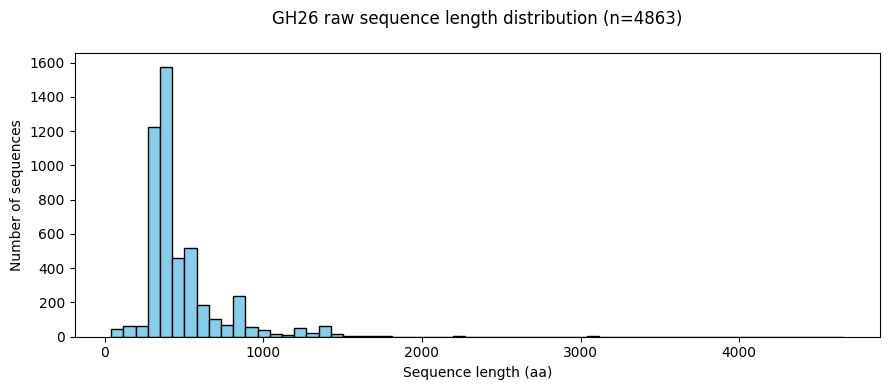

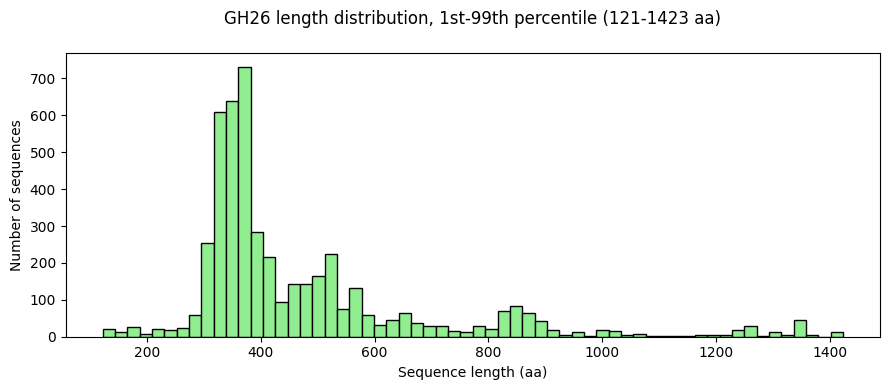


1st percentile: 121 aa, 99th percentile: 1423 aa
Use these plots to choose your own min/max length cutoff below.


In [20]:
# @title Analyze Sequence Length Distribution
import matplotlib.pyplot as plt
import numpy as np

# Extract sequence lengths from the records
lengths = [len(str(record.seq)) for record in records]

# Define a directory for saving plots
cluster_dir = work_dir # Using work_dir for now, can be changed later if needed

# Histogram for raw sequence length distribution
plt.figure(figsize=(9, 4))
plt.hist(lengths, bins=60, color='skyblue', edgecolor='black')
plt.xlabel("Sequence length (aa)")
plt.ylabel("Number of sequences")
plt.title(f"{GH_FAMILY} raw sequence length distribution (n={len(records)})\n")
plt.tight_layout()
plt.savefig(cluster_dir / "raw_length_distribution.png", dpi=150)
plt.show()

# Zoomed view of the bulk of the distribution (drop the extreme tail)
p1, p99 = np.percentile(lengths, [1, 99])
plt.figure(figsize=(9, 4))
plt.hist([l for l in lengths if p1 <= l <= p99], bins=60, color='lightgreen', edgecolor='black')
plt.xlabel("Sequence length (aa)")
plt.ylabel("Number of sequences")
plt.title(f"{GH_FAMILY} length distribution, 1st-99th percentile ({p1:.0f}-{p99:.0f} aa)\n")
plt.tight_layout()
plt.savefig(cluster_dir / "raw_length_distribution_zoomed.png", dpi=150)
plt.show()

print(f"\n1st percentile: {p1:.0f} aa, 99th percentile: {p99:.0f} aa")
print("Use these plots to choose your own min/max length cutoff below.")

# **QUESTIONS**
### How many sequences did you fetch ?

**Answer**
One of the output lines said the following: Loaded 7120 accessions from GH26/GH26_ncbi.txt, meaning that 7120 sequences (assuming that every accession has a unique sequence) were downloaded from NCBI.


### How many duplicate sequences ?

**Answer**
Another output line said the following: now contains 4863 unique sequences. This means that there were 2257 duplicate sequences fetched from NCBI (7120-4863)

### What is the average sequence length ?

**Answer**
Average sequence length: avg_len: 483.5 bp



---


# **3. Cluster with MMseqs2**
### Now we well cluster the sequence with MMseqs2 using easy-cluster and easy-search

## Cluster with MMseqs2

> **~100 MB download, about a minute.** This cell downloads the MMseqs2 binary and prints its full
> help text at the end. **That wall of text is expected** — it is the program confirming it runs, not
> an error.

In [21]:
# @title Install and Initialize MMseqs2
!wget https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz
!tar xzf mmseqs-linux-avx2.tar.gz

import os
os.environ["PATH"] += ":" + os.path.abspath("mmseqs/bin")

!mmseqs

--2026-09-11 14:22:15--  https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz
Resolving mmseqs.com (mmseqs.com)... 158.247.200.62
Connecting to mmseqs.com (mmseqs.com)|158.247.200.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19103130 (18M) [application/octet-stream]
Saving to: ‘mmseqs-linux-avx2.tar.gz’

mmseqs-linux-avx2.t 100%[===================>]  18.22M  10.9MB/s    in 1.7s    

2026-09-11 14:22:17 (10.9 MB/s) - ‘mmseqs-linux-avx2.tar.gz’ saved [19103130/19103130]

MMseqs2 (Many against Many sequence searching) is an open-source software suite for very fast, 
parallelized protein sequence searches and clustering of huge protein sequence data sets.

Please cite: M. Steinegger and J. Soding. MMseqs2 enables sensitive protein sequence searching for the analysis of massive data sets. Nature Biotechnology, doi:10.1038/nbt.3988 (2017).

MMseqs2 Version: a13af93468c997d73572c9326b69ac0c66c6583a
© Martin Steinegger (martin.steinegger@snu.ac.kr)

usage: mmseqs

## MMseqs2 Clustering and Bar Chart Visualization

### Clustering the family

MMseqs2 `easy-cluster` groups sequences that are similar enough to be treated as the same thing.
Two thresholds control it, and both are worth thinking about rather than accepting:

- **`MIN_SEQ_ID = 0.35`** — two sequences join a cluster if they are at least 35% identical. That is
  around the edge of the "twilight zone" where sequence identity stops being reliable evidence of
  homology, so it is a deliberately permissive setting.
- **`COVERAGE = 0.8`** — the alignment has to span 80% of the sequence. This is what stops a shared
  single domain from merging two otherwise unrelated multi-domain proteins.

Takes about a minute. Change the numbers and re-run to see how the family fragments or merges.

Filtering sequences by length: 4863 sequences reduced to 4197 (min=200, max=800 aa).
Running MMseqs2 easy-cluster with min-seq-id=0.35, coverage=0.8...

4197 sequences -> 398 clusters at 35% identity
56 clusters have >10 sequences

Largest clusters:
representative
ALI98489.1    541
QTN04148.1    362
AIT71003.1    331
QEC78578.1    169
BCI51186.1    135
VVW89043.1    120
BHQ65162.1    112
QWU13619.1    111
WHP16722.1    111
UKF80212.1    104
dtype: int64


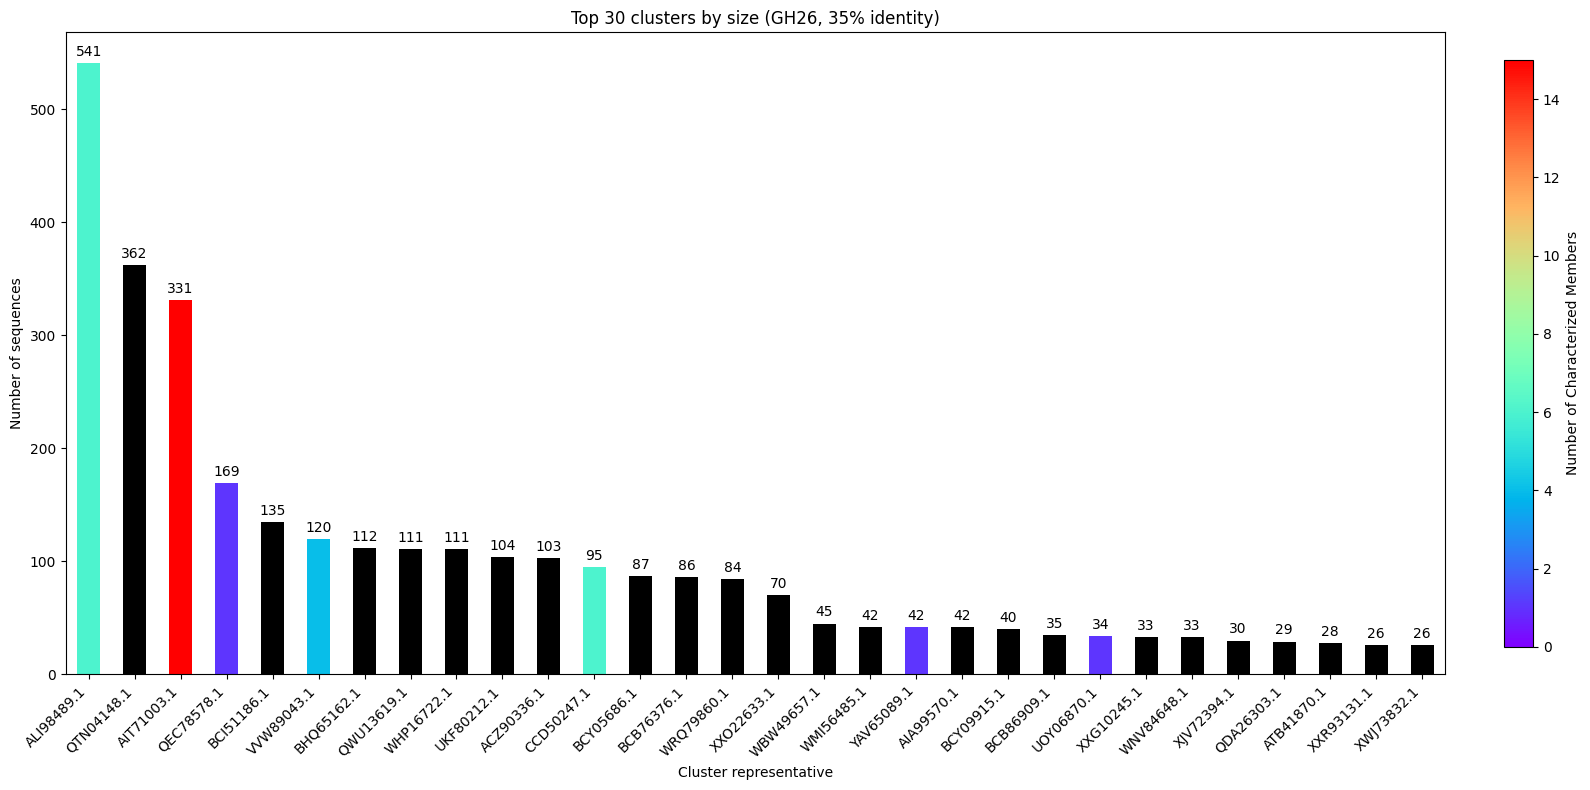

In [22]:
# @title MMseqs2 Clustering and Bar Chart Visualization - (top_n = Number of clusters to plot)
# What this cell does: groups the deduplicated sequences into clusters with MMseqs2 easy-cluster,
# then plots the sizes of the largest clusters. Two settings decide what 'similar enough' means:
#   MIN_SEQ_ID  - two sequences join a cluster if at least this fraction of aligned residues match
#   COVERAGE    - and the alignment must span at least this fraction of the sequence
# MIN_LENGTH / MAX_LENGTH drop fragments and fusion proteins before clustering.
### 4. MMseqs2 Clustering and Bar Chart Visualization
!pip install -q biopython
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO # Import SeqIO for FASTA handling

# Define temporary directory for MMseqs2
tmp_dir = work_dir / "mmseqs_tmp"
tmp_dir.mkdir(exist_ok=True)

# =======================================================================
# 4. MMseqs2 clustering at 35% identity (matches original workflow)
# =======================================================================
MIN_SEQ_ID = 0.35 # @param {type:"number"}
COVERAGE = 0.8 # @param {type:"number"}
MIN_LENGTH = 200 # @param {type:"number"}
MAX_LENGTH = 800 # @param {type:"number"}
top_n = 30 # @param {type:"number"} # Allow user to specify how many top clusters to visualize
INCLUDE_ACTIVITIES_COLORING = True # @param {type:"boolean"}
VERBOSE_MODE = False # @param {type:"boolean"}

# input_fasta and cluster_dir are already defined in previous cells
# input_fasta = work_dir / f"{GH_FAMILY}_ncbi.fasta"
# cluster_dir = work_dir # Set in cell 615126f7

# --- Apply sequence length filtering ---
# 'records' variable is expected to contain the deduplicated sequences from previous steps
if 'records' in globals() and records:
    initial_count = len(records)
    filtered_records = [rec for rec in records if MIN_LENGTH <= len(rec.seq) <= MAX_LENGTH]
    filtered_count = len(filtered_records)
    print(f"Filtering sequences by length: {initial_count} sequences reduced to {filtered_count} (min={MIN_LENGTH}, max={MAX_LENGTH} aa).")

    # Save the length-filtered sequences to a new FASTA file
    length_filtered_fasta = work_dir / f"{GH_FAMILY}_ncbi_deduplicated_length_filtered.fasta"
    with open(length_filtered_fasta, "w") as output_handle:
        SeqIO.write(filtered_records, output_handle, "fasta")

    input_fasta = length_filtered_fasta # Update input_fasta to use the filtered file
else:
    print("Warning: 'records' variable not found or empty. Skipping length filtering. Ensure previous cells were run.")
    print(f"Proceeding with input_fasta: {input_fasta}")


print(f"Running MMseqs2 easy-cluster with min-seq-id={MIN_SEQ_ID}, coverage={COVERAGE}...")

verbose_flag = "-v 3" if VERBOSE_MODE else "-v 0"
!mmseqs easy-cluster {input_fasta} {cluster_dir}/{GH_FAMILY.lower()}_cluster {tmp_dir} \
    --min-seq-id {MIN_SEQ_ID} -c {COVERAGE} --cov-mode 0 {verbose_flag}

cluster_tsv = cluster_dir / f"{GH_FAMILY.lower()}_cluster_cluster.tsv"

# Check if the cluster_tsv file exists before trying to read it
if cluster_tsv.exists():
    clusters = pd.read_csv(cluster_tsv, sep="\t", names=["representative", "member"])

    n_sequences = clusters["member"].nunique()
    n_clusters = clusters["representative"].nunique()
    print(f"\n{n_sequences} sequences -> {n_clusters} clusters at {MIN_SEQ_ID*100:.0f}% identity")

    cluster_sizes = clusters.groupby("representative").size().sort_values(ascending=False)
    n_large = (cluster_sizes > 10).sum()
    print(f"{n_large} clusters have >10 sequences")
    print("\nLargest clusters:")
    print(cluster_sizes.head(10))




    # =======================================================================
    # 5. Cluster size bar chart (matches "plotting no. of seqs in each
    #    cluster" slide)
    # =======================================================================

    # Ensure main_table is loaded if not already in global scope
    try:
        if 'main_table' not in globals() or main_table.empty:
            main_table = pd.read_csv("GH26_characterized.csv")
            print("Loaded GH26_characterized.csv for coloring data.")
    except FileNotFoundError:
        print("Warning: GH26_characterized.csv not found. Cannot color by characterized members.")
        main_table = pd.DataFrame() # Create empty DataFrame to avoid errors

    plt.figure(figsize=(16, 8))

    colors = [] # Initialize as empty list
    cmap = None
    norm = None
    cluster_char_counts_for_plot = pd.Series() # Initialize for potential colorbar

    if INCLUDE_ACTIVITIES_COLORING and not main_table.empty:
        characterized_genbanks = set(main_table['GenBank'].dropna().tolist())

        # Create a DataFrame that links every member to its representative and indicates if it's characterized
        all_members_with_reps = clusters.copy()
        all_members_with_reps['is_characterized'] = all_members_with_reps['member'].isin(characterized_genbanks)

        # Group by representative and sum the 'is_characterized' boolean (True=1, False=0)
        characterized_counts_per_rep = all_members_with_reps.groupby('representative')['is_characterized'].sum()

        # Filter for the top_n representatives being plotted
        plotting_rep_ids = cluster_sizes.head(top_n).index
        cluster_char_counts_for_plot = characterized_counts_per_rep.reindex(plotting_rep_ids, fill_value=0)

        max_char_count = cluster_char_counts_for_plot.max() if not cluster_char_counts_for_plot.empty else 0

        if max_char_count > 0:
            cmap = plt.colormaps['rainbow']
            norm = plt.Normalize(vmin=0, vmax=max_char_count)
            for count in cluster_char_counts_for_plot:
                if count == 0:
                    colors.append('black') # Color black if zero characterized members
                else:
                    colors.append(cmap(norm(count)))
        elif not cluster_char_counts_for_plot.empty and max_char_count == 0:
            # All top clusters have zero characterized members, color all black
            print("All top clusters have zero characterized members. Coloring bars black.")
            colors = ['black'] * top_n
        else:
            # This case means cluster_char_counts_for_plot was empty or had no relevant data
            print("No characterized data available for the top clusters. Using default blue.")
            colors = ['#1f77b4'] * top_n
    else:
        # Default blue if INCLUDE_ACTIVITIES_COLORING is False or main_table is empty
        colors = ['#1f77b4'] * top_n

    ax = cluster_sizes.head(top_n).plot(kind="bar", color=colors)
    plt.xlabel("Cluster representative")
    plt.ylabel("Number of sequences")
    plt.title(f"Top {top_n} clusters by size ({GH_FAMILY}, {MIN_SEQ_ID*100:.0f}% identity)")
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

    # Add numerical labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

    # Add color bar if activities coloring is enabled and there's data to color by
    if INCLUDE_ACTIVITIES_COLORING and cmap is not None and norm is not None and not cluster_char_counts_for_plot.empty and cluster_char_counts_for_plot.max() > 0:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array(cluster_char_counts_for_plot.values) # Important to set values for the colorbar
        cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
        cbar.set_label('Number of Characterized Members')

    plt.tight_layout()
    plt.savefig(cluster_dir / "top_clusters_barplot.png", dpi=150)
    plt.show()
else:
    print(f"Error: Cluster file not found at {cluster_tsv}. MMseqs2 clustering might have failed.")


# **QUESTIONS**
### 1. How many sequences have you clustered ?

**Answer:**
From the output: Filtering sequences by length: 4863 sequences reduced to 4197 (min=200, max=800 aa). This means that 4197 sequences passed the filtering and were clustered.


### 2. How many clusters do they form ?
**Answer:**
From output: 4197 sequences -> 398 clusters at 35% identity. This means that 398 clusters were formed.


### 3. How many clusters have more than 10 seqs ?
**Answer:**
From output: 56 clusters have >10 sequences.


### 4. Do you see any large uncharacterized clusters ?
**Answer**:
No not necesarilly? I'm also not sure how that's supposed to look? Does it then on the x-axis of the plot say 'uncharacterized'? If that is the case, then no.




---


# Now we can view which GH26 entry represent each cluster

In [23]:
# @title Sort Representative Sequences by Cluster Size and Save
from Bio import SeqIO

# Path to the FASTA file containing representative sequences
representative_fasta_path = cluster_dir / f"{GH_FAMILY.lower()}_cluster_rep_seq.fasta"

# Load the representative sequences
if representative_fasta_path.exists():
    representative_sequences = list(SeqIO.parse(representative_fasta_path, "fasta"))
    print(f"Loaded {len(representative_sequences)} representative sequences from {representative_fasta_path}")

    # Define the output path for the saved representative sequences
    output_representative_fasta = work_dir / f"{GH_FAMILY}_cluster_representatives.fasta"

    # Save them to a new FASTA file
    with open(output_representative_fasta, "w") as output_handle:
        SeqIO.write(representative_sequences, output_handle, "fasta")

    print(f"Saved representative sequences to {output_representative_fasta}")
else:
    print(f"Error: Representative sequences FASTA file not found at {representative_fasta_path}")

# Get the ordered list of representative IDs from cluster_sizes (already sorted by size)
sorted_rep_ids = cluster_sizes.index.tolist()

# Create a dictionary for quick lookup of SeqRecord objects by their ID
# We'll use the .id attribute for matching
rep_seq_dict = {seq_record.id.split()[0]: seq_record for seq_record in representative_sequences}

# Reorder the representative sequences based on sorted_rep_ids
sorted_representative_sequences = []
for rep_id in sorted_rep_ids:
    if rep_id in rep_seq_dict:
        sorted_representative_sequences.append(rep_seq_dict[rep_id])
    else:
        print(f"Warning: Representative ID {rep_id} not found in loaded sequences.")

# Overwrite the existing FASTA file with the sorted sequences
with open(output_representative_fasta, "w") as output_handle:
    SeqIO.write(sorted_representative_sequences, output_handle, "fasta")

print(f"Successfully sorted representative sequences and saved to {output_representative_fasta}")

Loaded 398 representative sequences from GH26/gh26_cluster_rep_seq.fasta
Saved representative sequences to GH26/GH26_cluster_representatives.fasta
Successfully sorted representative sequences and saved to GH26/GH26_cluster_representatives.fasta


In [24]:
# @title View FASTA Entries for representative from largest clusters

import Bio.SeqIO
from pathlib import Path # Ensure Path is imported

num_fasta_entries = 20 # @param {type:"number"}

# Ensure output_representative_fasta is defined (from cell ff1c29d1)
if 'output_representative_fasta' not in globals():
    print("Warning: 'output_representative_fasta' is not defined. Please ensure the clustering and sorting cells are run.")
    # Attempt to derive it if possible, or set a placeholder
    output_representative_fasta = Path(GH_FAMILY) / f"{GH_FAMILY}_cluster_representatives.fasta"
    if not output_representative_fasta.exists():
        print(f"Error: Representative FASTA file not found at expected path: {output_representative_fasta}")
        output_representative_fasta = None # Indicate it's not available


if output_representative_fasta and output_representative_fasta.exists():
    if num_fasta_entries > 0:
        print(f"Displaying first {num_fasta_entries} intact entries from {output_representative_fasta}:")
        count = 0
        with open(output_representative_fasta, "r") as f:
            for record in Bio.SeqIO.parse(f, "fasta"):
                # Print the full FASTA entry (ID + description + sequence)
                print(f">{record.id} {record.description.replace(record.id, '').strip()}") # Print ID and description
                print(str(record.seq)) # Print the sequence
                count += 1
                if count >= num_fasta_entries:
                    break
        if count == 0:
            print(f"No entries found in {output_representative_fasta}.")
    else:
        print("Please enter a positive number for 'Number of FASTA entries to display'.")
else:
    if output_representative_fasta: # Path was constructed but file doesn't exist
        print(f"The representative FASTA file does not exist at {output_representative_fasta}. Please ensure the previous steps creating this file have been executed successfully.")
    else: # output_representative_fasta was never properly defined
        print("Could not determine the path to the representative FASTA file.")

Displaying first 20 intact entries from GH26/GH26_cluster_representatives.fasta:
>ALI98489.1 beta-mannosidase [Rufibacter tibetensis]
MIRILLASFFLAFTFSSSGQTLTPINKKATPETRNLYANLKRLSQKGIMFGHQDALAYGMGWKYEPGRSDVKEIVGEYPAVVGWDLGHLELKHTVNLDSVPFDKMRQFAQEVYANGGLNTISWHLNNPLDPTKTSWDPMDSTIQHLFKDKKALKRYKSWLEDLAGFMRSLKGPNGELIPVIFRPLHEHTGSWFWWGRKHCSPEEYKQMWRFTVDYLRKKKANNLLFAYSTDRFTSREDYLERYPGDDYVDIVGFDIYHRPPADTAQLAQANQTFIKETRQMVETLRQIGQEKNKVWTLSETGLETLPIADWWTNVLTPIVKDAGLSYVMVWRNGRPDHYYAPYPGQKSEADFKTFYNNPNVFFIKKVAQEKLYAPPAQNK
>QTN04148.1 beta-mannosidase [Ochrobactrum sp. EEELCW01]
MKTSYKIATAILCGGLLSTAVYAASGVSGANVDTRNMFHDKRPVITRQSIKFGAYDPHGDFTNDPNSRIEHLFLPWEDVDLTSLSTADAYAQERGRELLITVEPWSWARDWRVAPDDLLSGIVRGHYDTNMAAVCSAASKLKSPVTIRWAQEMDDKTGQFTWSYWSAQGYVRAYQHAVNVCRKSLPNAKYMWSPKGDAGLEAYYPGDGYVDVIGLSVFGYEPYDMLELGHASTFVERTKPGYDRVVGFKKPIVIAELGYEGSDAYVRAWAQETNKPQPEFPELTATVYFNDREVYPWPRGVGRPDWRVANHPLD
>AIT71003.1 mannanase KMAN [synthetic construct]
MTSSTAVPANPSADNSAKKVYQWLNGLPDSNGKKLISGIFGGYSNIGGDSGFSLAQGNAIKDAT

## Get Members for a Specific Cluster Representative

Use the input field below to specify a cluster representative ID, and the cell will display all the member sequences belonging to that cluster.

In [25]:
# @title Display FASTA Entries grouped to a Cluster Representative
import pandas as pd
import Bio.SeqIO # Import SeqIO to handle FASTA records
from pathlib import Path # Ensure Path is imported for file paths

# Ensure sorted_rep_ids is available from previous cells (for potential future dropdown use, though currently manual input)
if 'sorted_rep_ids' not in globals():
    print("Warning: 'sorted_rep_ids' is not defined. Please ensure MMseqs2 clustering and sorting cells are run.")
    sorted_rep_ids = []

# Set a default representative ID, though it's an empty string for manual input
default_representative_id = ""

# @title Enter a cluster representative ID to view its members
cluster_representative_id = "BCI51186.1" # @param {type:"string", allow-input:true}

if 'clusters' in globals() and not clusters.empty:
    # Filter the clusters DataFrame for the selected representative
    if cluster_representative_id:
        members_in_cluster = clusters[clusters['representative'] == cluster_representative_id]['member'].tolist()

        if members_in_cluster:
            print(f"Intact FASTA entries for members of cluster represented by '{cluster_representative_id}':")

            # Path to the deduplicated FASTA file (assuming it's named GH_FAMILY_ncbi_deduplicated.fasta)
            # Ensure GH_FAMILY and work_dir are defined from previous cells
            if 'GH_FAMILY' not in globals() or 'work_dir' not in globals():
                print("Error: GH_FAMILY or work_dir is not defined. Cannot load sequences.")
                fasta_file_path = None
            else:
                fasta_file_path = Path(work_dir) / f"{GH_FAMILY}_ncbi_deduplicated.fasta"

            if fasta_file_path and fasta_file_path.exists():
                # Load all sequences into a dictionary for efficient lookup
                all_sequences = SeqIO.to_dict(SeqIO.parse(fasta_file_path, "fasta"))

                found_count = 0
                for member_id in members_in_cluster:
                    if member_id in all_sequences:
                        record = all_sequences[member_id]
                        # Print the full FASTA entry (ID + description + sequence)
                        print(f">{record.id} {record.description.replace(record.id, '').strip()}")
                        print(str(record.seq))
                        found_count += 1
                    else:
                        print(f"Warning: Member '{member_id}' not found in the FASTA file.")
                print(f"Total intact FASTA entries displayed: {found_count} out of {len(members_in_cluster)} members.")
            else:
                print(f"Error: FASTA file not found at {fasta_file_path}. Please ensure sequence fetching and deduplication steps are run.")

        else:
            print(f"No members found for cluster representative '{cluster_representative_id}'.")
            print("Please ensure the ID is correct and is a cluster representative.")
    else:
        print("No cluster representative selected. Please enter one.")
else:
    print("The 'clusters' DataFrame is not available. Please run the MMseqs2 clustering cell first.")

Intact FASTA entries for members of cluster represented by 'BCI51186.1':
>BCI51186.1 hypothetical protein NIIDNTM18_04640 [Mycolicibacterium litorale]
MRFGLSTPSGVFGLDEVAAVGAAVGRPVDVVLWYEDFAAAAPTAAVATVAAAGAAPVITWEPWLWRTDVTGTGAAMMSGIAAGEYDGHLRAWAGALSATATPVWLRFAHEFNGDWYPWSPVHGTTPQTYVAAWRHAHDLFASAGATSVRWVWSLDAATHGDIPLAAWYPGDAYVDVIGIDGYNWGTTHPWSRWTPPVEIFEPAATEVRALTHRPMMIAEVGCAEAGGSKADWITDFVRWVAAQPDVDAVVWFEHDKETDWRIASSPAATAAMAAALREAAA
>QNG36625.1 endoglucanase [Geodermatophilaceae bacterium NBWT11]
MVTFRIPGLLAALLVAGLLALVGATPAVAAPSLKPAKATGTAARPAAAAPAPTGRATALRFGVSVPGGPTASAELDASATAAGERPSVVLSYADFTTAPPLAGLDAVRARGADPVVTWEPWTWGSADRTRFSMSSIAAGAHDAYLRTWADSLRRWGSTVYLRFAHEQNGDWYPWSVGGGTTAADYTAAWRHVAQLFDQAGAGNVQFVWNPNVSYAGSSPMAATWPGADVVDVVGLDGYNWGTSQSWSSWQSPQTVFAGSLAELRTLAPGKPVVIGEVASAEAGGDKAAWIRDLVTWLDAQRDVAAVVWFDHAKETDWRIASSPASARALTTALDLRSGQHA
>SDP26859.1 Glycosyl hydrolase family 26 [Nakamurella panacisegetis]
MYHRTDPAKRRPRVGRRLTAVLATMTAMLLVTTALAPLERAVAAASTASPRMVGVTLPGAPTDLTALNALTVELGRKPTTVMWYQQWAGQP



---


# **4. Sequence Similarity Network (SSN)**

A Sequence Similarity Network (SSN) is a powerful tool for visualizing relationships between sequences.
It requires an all-vs-all pairwise search to determine edge weights based on sequence similarity.

First, we'll install `networkx` for graph manipulation and plotting.

In [26]:
# @title Install NetworkX (needed for SSN visualization)
!pip install -q networkx

Next, we perform an all-vs-all pairwise search using MMseqs2 in order to build an SSN on the full dataset

### ⏳ Slow cell — 3 to 10 minutes

A sequence similarity network needs every sequence compared against **every other sequence**, so the
work grows with the square of the dataset. On a few thousand sequences that is a few minutes on
Colab's CPU, and there is little output while it runs.

The result is cached to `ssn/allvall.tsv`. **Re-running this cell afterwards is instant** — it detects
the existing file and skips the search. To genuinely redo it, delete the file first.

In [27]:
# @title all-vs-all pairwise search using MMseqs2 - (you can apply filters if needed)
# What this cell does: runs MMseqs2 easy-search with the family as BOTH query and target, so
# every sequence is aligned against every other. The output is one row per pair that aligned,
# with identity, alignment length, E-value and bit score - the raw material for the network.
# The result is written to ssn/allvall.tsv and reused if it already exists.
import subprocess
import os

MIN_SSN_SEQ_ID = 0 # @param {type:"number"} Minimum sequence identity for SSN edges
SSN_COVERAGE = 0 # @param {type:"number"} Minimum coverage for SSN edges

# The full deduplicated sequences FASTA file (around 4000 sequences)
# `input_fasta` was defined earlier in the notebook as work_dir / f"{GH_FAMILY}_ncbi_deduplicated.fasta"
ssn_input_fasta = input_fasta

# Define directories for SSN related files
ssn_dir = work_dir / "ssn"
ssn_dir.mkdir(exist_ok=True)
ssn_tmp = ssn_dir / "tmp"
ssn_tmp.mkdir(exist_ok=True)

allvall_tsv_path = ssn_dir / "allvall.tsv"

# Check if the output file already exists
if not allvall_tsv_path.exists():
    print(f"Running mmseqs easy-search on {ssn_input_fasta} against itself...")

    # Execute mmseqs easy-search command
    try:
        command = [
            "mmseqs", "easy-search",
            ssn_input_fasta.as_posix(),  # Query database
            ssn_input_fasta.as_posix(),  # Target database
            allvall_tsv_path.as_posix(), # Output TSV
            ssn_tmp.as_posix(),    # Temporary directory
            "--format-output", "query,target,pident,alnlen,evalue,bits",
            "-s", str(MIN_SSN_SEQ_ID),          # Sensitivity, now controlled by param
            "-c", str(SSN_COVERAGE) ,
            "--cov-mode", "0",
            "--max-seqs", "1000"  # Max number of sequences to retrieve per query
        ]
        result = subprocess.run(command, capture_output=True, text=True, check=True)
        print("All-vs-all search complete.")
        print(f"Results saved to {allvall_tsv_path}")
    except subprocess.CalledProcessError as e:
        print(f"Error running mmseqs easy-search: {e}")
        print(f"Stdout: {e.stdout}")
        print(f"Stderr: {e.stderr}")
    except FileNotFoundError:
        print("Error: mmseqs command not found. Ensure MMseqs2 is installed and in your PATH.")
else:
    print(f"All-vs-all search results already found at {allvall_tsv_path}. Skipping re-run.")
    print("If you wish to re-run the search, delete the file manually.")

Running mmseqs easy-search on GH26/GH26_ncbi_deduplicated_length_filtered.fasta against itself...
All-vs-all search complete.
Results saved to GH26/ssn/allvall.tsv


Now we load the pairwise search results and prepare them for network construction. We will remove self-hits as they are not informative for network edges.

In [28]:
# @title Load Pairwise Search Results
import pandas as pd
import networkx as nx

# Load the pairwise search results
allvall_tsv_path = ssn_dir / "allvall.tsv"
pairs = pd.read_csv(
    allvall_tsv_path,
    sep="\t",
    names=["query", "target", "pident", "alnlen", "evalue", "bits"],
)

# Remove self-hits (where query is the same as target)
pairs = pairs[pairs["query"] != pairs["target"]]
print(f"{len(pairs)} pairwise hits (self-hits removed)")
display(pairs.head())
display(pairs.tail())

1795587 pairwise hits (self-hits removed)


,query,target,pident,alnlen,evalue,bits
1,AJK59586.1,XYC15481.1,68.0,316,1.415000e-145,455
2,AJK59586.1,XDQ45809.1,73.3,270,6.309000e-141,442
3,AJK59586.1,ANN21679.1,72.8,269,1.653000e-137,432
4,AJK59586.1,WLQ62184.1,64.8,302,7.225000e-136,427
5,AJK59586.1,XKJ62728.1,71.7,269,1.356000e-135,426


,query,target,pident,alnlen,evalue,bits
1799779,YCH01534.1,BBE21309.1,32.7,100,0.000005,46
1799780,YCH01534.1,WPT18075.1,28.5,127,0.000005,46
1799781,YCH01534.1,XJO70878.1,37.2,59,0.000104,42
1799782,YCH01534.1,WIA31117.1,23.4,139,0.000183,41
1799783,YCH01534.1,AGT80112.1,75.0,20,0.000320,40


## Choose SSN edge thresholds.

This is the crucial step for defining the network. You can adjust `MIN_PIDENT` (minimum percentage identity) and `MAX_EVALUE` (maximum E-value) and `MIN_BITS` (minimum bitscore) to control the stringency of the connections (edges) in your network.

Experimenting with these values is key to exploring the sequence space and identifying subfamilies.

In [29]:
# @title Choose SSN edge thresholds. You can set minimum percent identity (MIN_PIDENT), maximum E-value (MAX_EVALUE), and minimum bit score (MIN_BITS)
# What this cell does: keeps only the pairs that pass all three thresholds, then draws an edge
# between each surviving pair to build the network. Loosen the thresholds and more pairs connect
# (bigger components); tighten them and the network fragments into subfamilies.
#   MIN_PIDENT - minimum % identity        MAX_EVALUE - maximum E-value (smaller = stricter)
#   MIN_BITS   - minimum bit score         (bit score and E-value are explained in Exercise 1)
MIN_PIDENT = 25 # @param {type:"number"} # minimum % identity to draw an edge
MAX_EVALUE = 1e-100 # @param ["1e-10","1e-15","1e-20","1e-25","1e-30","1e-35","1e-40","1e-45","1e-50","1e-55","1e-60","1e-65","1e-70","1e-75","1e-80","1e-85","1e-90","1e-95","1e-100","1e-105","1e-110","1e-115","1e-120","1e-125","1e-130","1e-135","1e-140","1e-145","1e-150","1e-155","1e-160","1e-165","1e-170","1e-175","1e-180","1e-185","1e-190","1e-195","1e-200"] {"type":"raw"}
MIN_BITS = 100 # @param {type:"number"} # minimum bit score to draw an edge

# Filter edges based on the chosen thresholds
edges = pairs[(pairs["pident"] >= MIN_PIDENT) & (pairs["evalue"] <= MAX_EVALUE) & (pairs["bits"] >= MIN_BITS)]
print(f"{len(edges)} edges pass threshold (pident >= {MIN_PIDENT}%, evalue <= {MAX_EVALUE}, bits >= {MIN_BITS})")

# Build the NetworkX graph
G = nx.Graph()
for _, row in edges.iterrows():
    G.add_edge(row["query"], row["target"], weight=row["bits"], pident=row["pident"])

# Report network statistics
print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
      f"{nx.number_connected_components(G)} connected components")

381395 edges pass threshold (pident >= 25%, evalue <= 1e-100, bits >= 100)
Network: 4021 nodes, 194509 edges, 165 connected components


### Exploring Different Thresholds

This is the core exploratory exercise with SSNs. There isn't a single 'correct' threshold for `MIN_PIDENT`, `MAX_EVALUE` and `MIN_BITS`. You should try different combinations and rerun the cell **Choose an edge threshold** and build the graph' onwards to observe how the network resolves or merges into different connected components (clusters).

This helps in understanding the evolutionary relationships within the protein family.

## SSN Visualization

Now we can visualize the SSN using `matplotlib` with a force-directed layout. Nodes will be colored by their connected component, offering a rough visualization of potential subfamily groupings. To better visualize individual clusters we arrange them in a grid-like fashion.

(Default: number of columns: 15, Spacing factors: 1, base cell unit: 5, scaling 0.5)

> **Takes 1–3 minutes.** The layout algorithm pushes every node apart from every other node
> iteratively, so a large network is slow to draw and the plot appears only at the very end.
>
> This cell and the threshold cell above are the exploratory loop: change `MIN_PIDENT` / `MAX_EVALUE`
> / `MIN_BITS`, re-run both, and watch the network fragment or merge. You do **not** need to re-run
> the all-vs-all search in between.

Highlighted 55 characterized nodes as yellow stars.


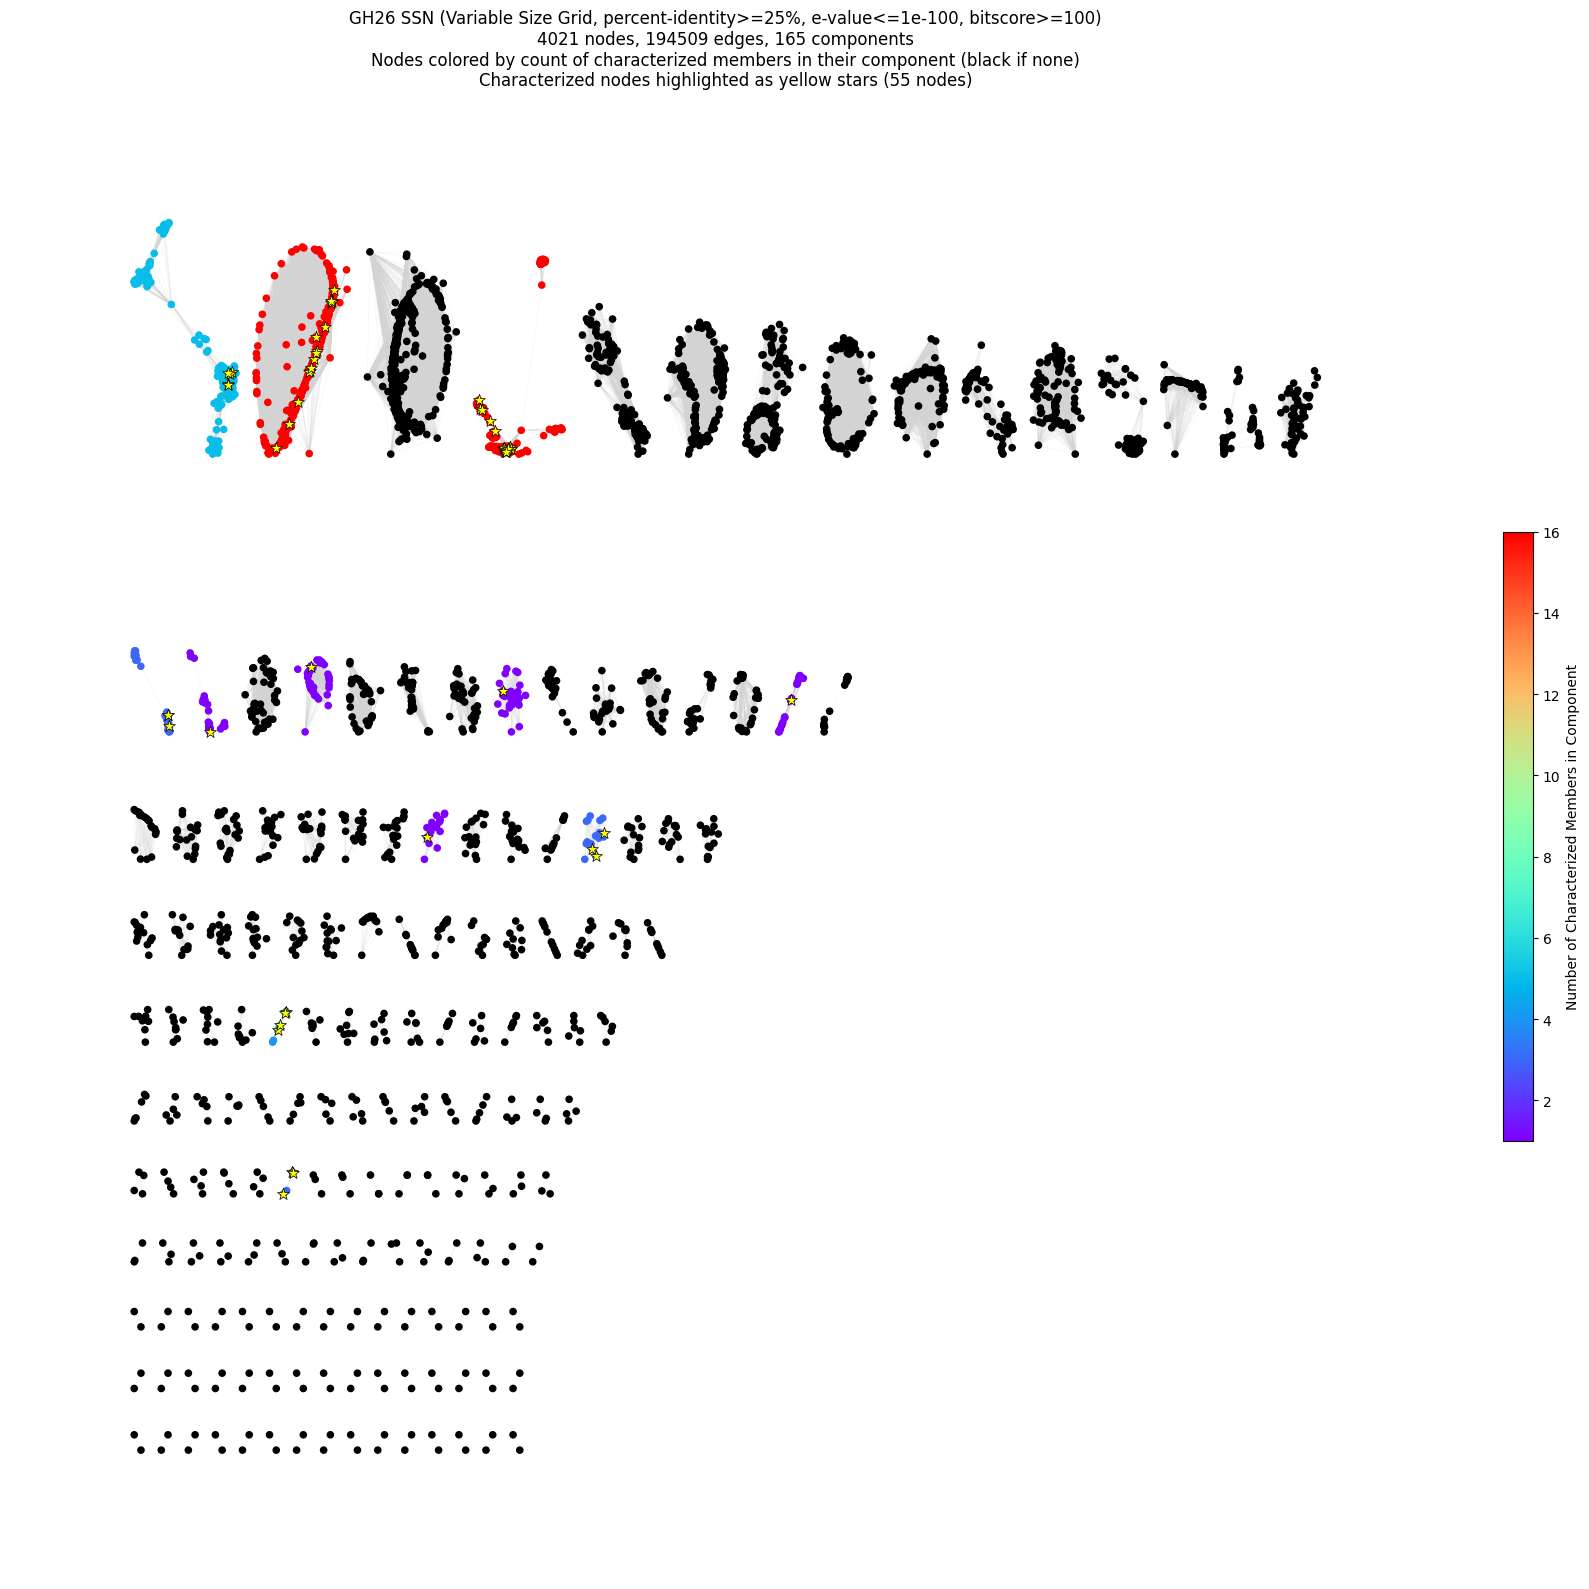

In [30]:
# @title SSN arranged in rows and colored by characterized members
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

# --- Configuration for grid arrangement ---
NUM_COLUMNS = 15 # @param {type:"integer"} # Number of columns for arranging components
SPACING_FACTOR_X = 1 # @param {type:"number"} # Horizontal spacing between components (increased for better separation)
SPACING_FACTOR_Y = 1 # @param {type:"number"} # Vertical spacing between components (increased for better separation)
# NODE_COLORMAP = "viridis" # @param ["viridis", "plasma", "inferno", "magma", "cividis", "rainbow", "jet", "hsv", "tab10", "tab20"] {type:"string"} # Colormap for nodes

# --- Configuration for component size scaling ---
BASE_CELL_UNIT = 5 # @param {type:"number"} # Base unit size for component layout. Larger value = larger overall components.
SCALING_EXPONENT = 0.5 # @param {type:"number"} # Exponent for non-linear scaling. 0.0 = uniform size, 1.0 = linear scaling by node count, 0.5 = square root scaling.

# --- New parameter for highlighting characterized nodes ---
HIGHLIGHT_CHARACTERIZED_NODES = True # @param {type:"boolean"}

plt.figure(figsize=(16, 16)) # Adjust figure size for a grid layout

# Get connected components and sort them by size (largest first) for better packing
components = sorted(nx.connected_components(G), key=len, reverse=True)

# Calculate max nodes in any component for scaling, avoid division by zero
if components:
    max_nodes_in_any_component = max(len(c) for c in components)
else:
    max_nodes_in_any_component = 1 # Default to 1 to avoid division by zero

# Dictionary to store final positions for all nodes
final_pos = {}

# Variables for grid positioning
current_x_offset = 0.0
current_y_offset = 0.0
row_max_height = 0.0 # Track max height in current row for y_offset adjustment

current_col = 0

# Store component IDs for node coloring later
comp_id = {}

for i, component_nodes in enumerate(components):
    subgraph = G.subgraph(component_nodes)

    # Calculate current component's target display size based on its node count
    if SCALING_EXPONENT == 1.0: # Uniform size
        current_component_display_size = BASE_CELL_UNIT * 0.5 # A fixed base unit if scaling is off
    elif len(component_nodes) == 1:
        current_component_display_size = BASE_CELL_UNIT * 0.2 # Minimum size for singletons
    else:
        current_component_display_size = BASE_CELL_UNIT * (len(component_nodes) / max_nodes_in_any_component)**SCALING_EXPONENT

    # Apply a layout to the individual component
    # Keep 'k' relatively small for internal compactness, and let external scaling handle the size
    # Using a 'k' proportional to the component's internal spread but not its grid size.
    # Using fruchterman_reingold_layout as it usually gives better separation for subgraphs.
    comp_pos = nx.fruchterman_reingold_layout(subgraph, k=0.001, iterations=50, seed=42 + i)

    # Get bounding box of the layout for internal normalization
    min_x = min(p[0] for p in comp_pos.values())
    max_x = max(p[0] for p in comp_pos.values())
    min_y = min(p[1] for p in comp_pos.values())
    max_y = max(p[1] for p in comp_pos.values())

    # Ensure range is not zero for single-node components or very tight layouts
    x_range_comp = (max_x - min_x) if max_x > min_x else 1.0
    y_range_comp = (max_y - min_y) if max_y > min_y else 1.0

    # Scale the internal layout of the component to fit within its calculated display size
    scaled_comp_pos = {
        node:
            (
                (p[0] - min_x) / x_range_comp * current_component_display_size,
                (p[1] - min_y) / y_range_comp * current_component_display_size,
            )
        for node, p in comp_pos.items()
    }

    # The actual width and height this component will occupy on the grid
    component_actual_width = current_component_display_size
    component_actual_height = current_component_display_size

    # Check if we need to start a new row
    if current_col >= NUM_COLUMNS:
        current_col = 0
        current_y_offset -= (row_max_height + SPACING_FACTOR_Y) # Move down by max height of previous row
        current_x_offset = 0.0
        row_max_height = 0.0 # Reset max height for new row

    # Update max height for the current row
    row_max_height = max(row_max_height, component_actual_height)

    # Add shifted positions to the final_pos dictionary
    for node, (x, y) in scaled_comp_pos.items():
        final_pos[node] = (x + current_x_offset, y + current_y_offset)
        comp_id[node] = i # Store component ID for coloring

    # Update x_offset for the next component in the current row
    current_x_offset += component_actual_width + SPACING_FACTOR_X
    current_col += 1


# --- Drawing the network ---

# Assign node sizes: making all nodes the same size
node_sizes_base = 20 # Base size for all nodes
node_sizes = [node_sizes_base] * len(G.nodes())


# Custom coloring logic based on characterized members in each component
# `main_table` is expected to be available from previous cells.
characterized_genbanks = set(main_table['GenBank'].dropna().tolist())

component_char_counts = {}
for i, comp_nodes in enumerate(components):
    count = 0
    for node in comp_nodes:
        if node in characterized_genbanks:
            count += 1
    component_char_counts[i] = count

node_colors_final = []
max_char_count_overall = max(component_char_counts.values()) if component_char_counts else 0

if max_char_count_overall > 0:
    cmap = plt.colormaps['rainbow'] # User requested 'rainbow'
    norm = plt.Normalize(vmin=1, vmax=max_char_count_overall) # vmin=1 so 0 is distinct

    for node in G.nodes():
        comp_idx = comp_id.get(node, -1) # Get component index for the node
        char_count = component_char_counts.get(comp_idx, 0)

        if char_count == 0:
            node_colors_final.append('black') # Clusters with no characterized members are black
        else:
            node_colors_final.append(cmap(norm(char_count)))
else:
    # If no characterized members in any component, all nodes are black
    node_colors_final = ['black'] * len(G.nodes())
    print("No characterized members found in any component. All nodes will be colored black.")

nx.draw_networkx_edges(G, final_pos, alpha=0.2, width=0.5, edge_color='lightgrey')

# Draw all nodes with their component-based coloring
nx.draw_networkx_nodes(G, final_pos, node_size=node_sizes, node_color=node_colors_final)

highlight_nodes = [] # Initialize for title check
# Highlight characterized nodes if the parameter is True
if HIGHLIGHT_CHARACTERIZED_NODES:
    highlight_nodes = [node for node in G.nodes() if node in characterized_genbanks]
    if highlight_nodes:
        # Draw characterized nodes as yellow stars, larger than other nodes
        nx.draw_networkx_nodes(
            G, final_pos,
            nodelist=highlight_nodes,
            node_size=node_sizes_base * 4, # Make them significantly larger
            node_color='yellow',
            node_shape='*', # Star shape
            edgecolors='black', # Add a black border for definition
            linewidths=0.5, # Border width
            alpha=1.0 # Ensure they are fully visible
        )
        print(f"Highlighted {len(highlight_nodes)} characterized nodes as yellow stars.")
    else:
        print("No characterized nodes found to highlight.")


# Add a colorbar if there are characterized members
if max_char_count_overall > 0:
    # Create a dummy scalar mappable for the colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array(list(range(1, max_char_count_overall + 1)))
    cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', fraction=0.02, pad=0.04)
    cbar.set_label('Number of Characterized Members in Component')

title_text = (f"{GH_FAMILY} SSN (Variable Size Grid, percent-identity>={MIN_PIDENT}%, e-value<={MAX_EVALUE}, bitscore>={MIN_BITS})\n"
              f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
              f"{len(components)} components\n"
              f"Nodes colored by count of characterized members in their component (black if none)")
if HIGHLIGHT_CHARACTERIZED_NODES and highlight_nodes:
    title_text += f"\nCharacterized nodes highlighted as yellow stars ({len(highlight_nodes)} nodes)"
plt.title(title_text)
plt.axis("off")
plt.tight_layout()
plt.savefig(ssn_dir / "ssn_grid_variable_size_char_colored.png", dpi=150) # New filename
plt.show()

# **QUESTIONS**
### 1. How many large clusters do you find ?

**Answer:**
I'm not sure about this one. Could be: 381395 edges pass threshold (pident >= 25%, evalue <= 1e-100, bits >= 100)
Network: 4021 nodes, 194509 edges, 165 connected components. I'm not sure if node and cluster is the same thing. If so, then there are 4021 clusters? Not sure how many are large clusters though.


### 2. Where are the characterized members ?

**Answer**:
The charachterized large members are all located together on several clusters and are colored (some also marked with a yellow star).

### 3. Do you see any large uncharacterized clusters ?

**Asnwer**:
Yes, there appear to be several large uncharacterized clusters (those are all the clusters marked in black). This appears to be the majority of the clusters.



---


# **OPTIONAL:**

## Visualize an interactive SSN in Cytoscape

In [31]:
# @title Export SSN to GraphML format and open in Cytoscape
from google.colab import files
import networkx as nx

# Ensure ssn_dir and GH_FAMILY are defined from previous cells
# G is also expected to be defined from previous SSN construction steps

output_graphml_path = ssn_dir / f"{GH_FAMILY}_ssn.graphml"

# --- Add node attributes for Cytoscape visualization ---
# Retrieve necessary data from previous cells' execution state
# `main_table` is expected to contain characterized members
# `comp_id` maps nodes to their component index
# `component_char_counts` stores characterized member counts per component index

# 1. Identify characterized nodes
characterized_genbanks = set(main_table['GenBank'].dropna().tolist())

# 2. Iterate through each node in the graph and add attributes
for node_id in G.nodes():
    # Add 'is_characterized' attribute
    is_char = node_id in characterized_genbanks
    G.nodes[node_id]['is_characterized'] = is_char

    # Add 'characterized_members_in_component' attribute
    component_index = comp_id.get(node_id) # Get the component index for the current node
    if component_index is not None:
        char_count_in_component = component_char_counts.get(component_index, 0)
        G.nodes[node_id]['characterized_members_in_component'] = char_count_in_component
    else:
        # Should not happen if comp_id is correctly populated for all nodes in G
        G.nodes[node_id]['characterized_members_in_component'] = 0

# Ensure the GraphML file is created before attempting to download
print(f"Exporting the graph to GraphML: {output_graphml_path}")
nx.write_graphml(G, output_graphml_path)
print("Graph exported successfully with 'is_characterized' and 'characterized_members_in_component' attributes.")

if output_graphml_path.exists():
    print(f"Downloading {output_graphml_path.name}...")
    files.download(output_graphml_path)
else:
    print(f"Error: GraphML file not found at {output_graphml_path} after export attempt.")
    print("Please ensure the SSN creation steps have been executed successfully and 'G' is defined.")

Exporting the graph to GraphML: GH26/ssn/GH26_ssn.graphml
Graph exported successfully with 'is_characterized' and 'characterized_members_in_component' attributes.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>